## Assignment: changes in protein levels in mouse optical nerve following light deprivation 

Scenario: you have performed a study where 20 mice were deprived of any light until their adulthood. The mice were then sacrified to measure the concentration of 7 proteins (Atoh7, Brn3a, Pou4f1, Brn3b, Pou4f2, Brn3c, Pou4f3) in the optical nerve. The same procedure was performed on 20 control mice that experienced normal day / night cycles during their lives. 

### Exercise 1

- Read the excel file "data.xlsx" in a pandas data frame named "data". 
- Plot boxplots for each protein.
- Plot boxplots for each protein stratified by Group.

In [11]:
# setting up matplotlib so that all plots show nicely in the cell output
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [26]:
## Read the excel file "data.xlsx" in a pandas data frame named "data".

import pandas as pd
data = pd.read_excel('./data.xlsx', index_col = 'Mouse ID')
data.head()

,Group,Atoh7,Brn3a,Pou4f1,Brn3b,Pou4f2,Brn3c,Pou4f3
Mouse ID,,,,,,,,
C1,Control,11.921905,10.110226,11.089228,10.893175,11.042669,10.034822,11.639170
C2,Control,10.096563,10.813420,10.886038,10.951197,12.626412,10.551360,10.504414
C3,Control,10.066854,10.214251,11.598919,11.145795,11.646962,10.109896,11.753371
C4,Control,10.523677,12.701459,11.475043,13.231947,12.730997,12.477995,10.555008
C5,Control,11.623593,11.998176,10.775375,12.386329,10.924830,11.357421,11.057788


Text(0.5, 0, 'Proteins')

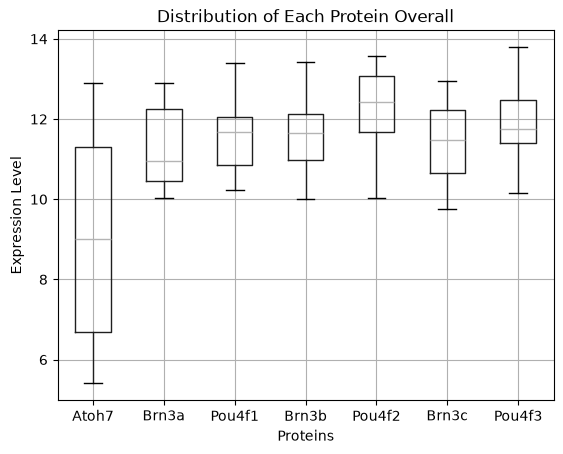

In [32]:
## Plot boxplots for each protein.
data.boxplot()
plt.title('Distribution of Each Protein Overall')
plt.ylabel('Expression Level')
plt.xlabel('Proteins')

Control                   Axes(0.1,0.15;0.363636x0.75)
Light_Deprivation    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

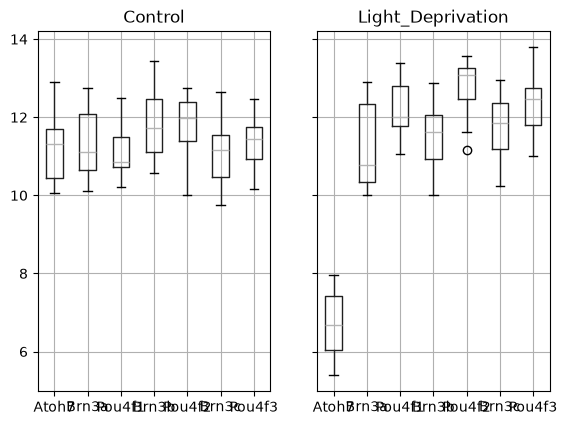

In [56]:
## Plot boxplots for each protein stratified by Group.
data_2 = data.groupby('Group')
data_2.boxplot()

### Exercise 2

- Use the ttest_ind function contained in the package scipy.stats for assessing the statistical significance of the difference in protein concentration between control and ligh-deprivation groups for the Atoh7 protein.

Looking at google, I've found that by default, ttest_ind assumes two things:

- Your two groups have equal variances.
- Your data follows a normal distribution.

In [116]:
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import kruskal


control = data[data['Group'] == 'Control']['Atoh7']
ld = data[data['Group'] == 'Light_Deprivation']['Atoh7']

n_1 = shapiro(control)
n_2 = shapiro(ld)

print(f"Shapiro Control: \n {n_1} \n\n")
print(f"Shapiro LD: \n {n_2}\n\n")

# Just to save a bit of time I will check my data using the Welch test. 
res = ttest_ind(
    data_Atoh7_Control,
    data_Atoh7_LD,
    equal_var=False,
)

print(f"t-test results: \n {res}")



Shapiro Control: 
 ShapiroResult(statistic=np.float64(0.947883390023381), pvalue=np.float64(0.3361009028060275)) 


Shapiro LD: 
 ShapiroResult(statistic=np.float64(0.9347133750422862), pvalue=np.float64(0.19019225821396912))


t-test results: 
 TtestResult(statistic=np.float64(17.70730356453135), pvalue=np.float64(7.35219414906592e-20), df=np.float64(37.689931458479506))


As we can see in the results above, both sets could be considered normal distributed, and the t-test pvalue <<< 0.05, therefore we reject the null hypothesis of having a equal mean, there is a significant difference among our samples!

### Exercise 3

- Use a for loop for computing a similar t-test for each protein.
- Which proteins show a statistically significant difference?

In [117]:
# Without correcting based on the normality
proteins = list(data)[1:]

def t_test(data, proteins):
    control_normality = []
    ld_normality = []
    t_test_pvalue = []
    
    for i in proteins:    
        control = data[data['Group'] == 'Control'][i]
        ld = data[data['Group'] == 'Light_Deprivation'][i]
        
        n_1 = shapiro(control).pvalue
        n_2 = shapiro(ld).pvalue
        
        res = ttest_ind(
            control,
            ld,
            equal_var=False).pvalue
        
        control_normality.append(n_1)
        ld_normality.append(n_2)
        t_test_pvalue.append(res)
    return (control_normality, ld_normality, t_test_pvalue)

control_normality, ld_normality, t_test_pvalue = t_test(data, proteins)

# Let's create the solution data frame
result = {"t-test": t_test_pvalue, "Control": control_normality, "LD": ld_normality}
df_result = pd.DataFrame(result, index=proteins)
df_result

,t-test,Control,LD
Atoh7,7.352194e-20,0.336101,0.190192
Brn3a,8.653487e-01,0.047493,0.003782
Pou4f1,2.915780e-06,0.088535,0.086984
Brn3b,2.781013e-01,0.141191,0.824721
Pou4f2,2.325475e-04,0.167747,0.022574
Brn3c,3.988034e-02,0.381251,0.288514
Pou4f3,3.460029e-05,0.386979,0.970805


In [129]:
# Correcting with the normality
proteins = list(data)[1:]

def t_test(data, proteins):
    control_normality = []
    ld_normality = []
    type_test = []
    test_pvalue = []
    
    
    for i in proteins:    
        control = data[data['Group'] == 'Control'][i]
        ld = data[data['Group'] == 'Light_Deprivation'][i]
        
        n_1 = shapiro(control).pvalue
        n_2 = shapiro(ld).pvalue

        if n_1 <= 0.05 or n_2 <= 0.05:
            res = kruskal(control, ld).pvalue
            type_test.append('KRUSKAL')
        else: 
            res = ttest_ind(
                control,
                ld,
                equal_var=False).pvalue
            type_test.append('T-TEST')
        
        control_normality.append(n_1)
        ld_normality.append(n_2)
        test_pvalue.append(res)
        
    return (control_normality, ld_normality, test_pvalue, type_test)

control_normality, ld_normality, t_test_pvalue, type_test = t_test(data, proteins)

# Let's create the solution data frame
result = {"Test": t_test_pvalue, 
          "Type Test" : type_test, 
          "Control": control_normality, 
          "LD": ld_normality}

df_result = pd.DataFrame(result, index=proteins)

print("Before filtering")
print(df_result)

df_result_2 = df_result[df_result['Test'] < 0.05]
print("\n \n Final results")
print(df_result_2)

print(f'\n Only the following proteins showed a different expresion level: {df_result_2.index.values.tolist()}')

Before filtering
                Test Type Test   Control        LD
Atoh7   7.352194e-20    T-TEST  0.336101  0.190192
Brn3a   6.456228e-01   KRUSKAL  0.047493  0.003782
Pou4f1  2.915780e-06    T-TEST  0.088535  0.086984
Brn3b   2.781013e-01    T-TEST  0.141191  0.824721
Pou4f2  5.917643e-04   KRUSKAL  0.167747  0.022574
Brn3c   3.988034e-02    T-TEST  0.381251  0.288514
Pou4f3  3.460029e-05    T-TEST  0.386979  0.970805

 
 Final results
                Test Type Test   Control        LD
Atoh7   7.352194e-20    T-TEST  0.336101  0.190192
Pou4f1  2.915780e-06    T-TEST  0.088535  0.086984
Pou4f2  5.917643e-04   KRUSKAL  0.167747  0.022574
Brn3c   3.988034e-02    T-TEST  0.381251  0.288514
Pou4f3  3.460029e-05    T-TEST  0.386979  0.970805

 Only the following proteins showed a different expresion level: ['Atoh7', 'Pou4f1', 'Pou4f2', 'Brn3c', 'Pou4f3']


### Exercise 4

- Create two different datasets, namely "control" and "ld", the first one with the data from the Control group and the second one with the data from the Light Deprivation group.
- Compute a correlation matrix for the control dataframe. The matrix should contain the correlation coefficients between all pairs of protein.
- Compute a similar correlation matrix for the ld dataframe.

In [142]:
# Create two different datasets, namely "control" and "ld", the first one with the data from the 
# Control group and the second one with the data from the Light Deprivation group.
control = data[data['Group'] == 'Control']
ld = data[data['Group'] == 'Light_Deprivation']

In [149]:
# Compute a correlation matrix for the control dataframe. 
# The matrix should contain the correlation coefficients between all pairs of protein.

control_cor = control.corr(
    method = 'spearman',
    numeric_only = True
)
control_cor.style.background_gradient(cmap='Blues')

,Atoh7,Brn3a,Pou4f1,Brn3b,Pou4f2,Brn3c,Pou4f3
Atoh7,1.000000,0.025564,-0.348872,-0.081203,-0.431579,-0.079699,0.239098
Brn3a,0.025564,1.000000,-0.228571,0.909774,0.330827,0.915789,-0.094737
Pou4f1,-0.348872,-0.228571,1.000000,-0.200000,0.013534,-0.225564,-0.254135
Brn3b,-0.081203,0.909774,-0.200000,1.000000,0.320301,0.929323,-0.070677
Pou4f2,-0.431579,0.330827,0.013534,0.320301,1.000000,0.445113,-0.126316
Brn3c,-0.079699,0.915789,-0.225564,0.929323,0.445113,1.000000,0.075188
Pou4f3,0.239098,-0.094737,-0.254135,-0.070677,-0.126316,0.075188,1.000000


In [148]:
# Compute a similar correlation matrix for the ld dataframe.

ld_cor = ld.corr(
    method = 'spearman',
    numeric_only = True
)

ld_cor.style.background_gradient(cmap='Blues')

,Atoh7,Brn3a,Pou4f1,Brn3b,Pou4f2,Brn3c,Pou4f3
Atoh7,1.000000,-0.324812,0.375940,-0.012030,-0.312782,0.309774,0.064662
Brn3a,-0.324812,1.000000,-0.418045,-0.332331,0.130827,-0.046617,0.055639
Pou4f1,0.375940,-0.418045,1.000000,-0.142857,0.156391,-0.031579,-0.069173
Brn3b,-0.012030,-0.332331,-0.142857,1.000000,-0.470677,-0.166917,0.139850
Pou4f2,-0.312782,0.130827,0.156391,-0.470677,1.000000,0.303759,-0.324812
Brn3c,0.309774,-0.046617,-0.031579,-0.166917,0.303759,1.000000,-0.075188
Pou4f3,0.064662,0.055639,-0.069173,0.139850,-0.324812,-0.075188,1.000000


### Exercise 5

- Use the function heatmap from the package seaborn for displaying the correlation matrices of the control and ld dataframes. Use the 'coolwarm' colormap.
- Are Brn3a, Brn3b, and Brn3c highly correlated in controls? Are they still highly correlated in the light deprivation group?

<Axes: >

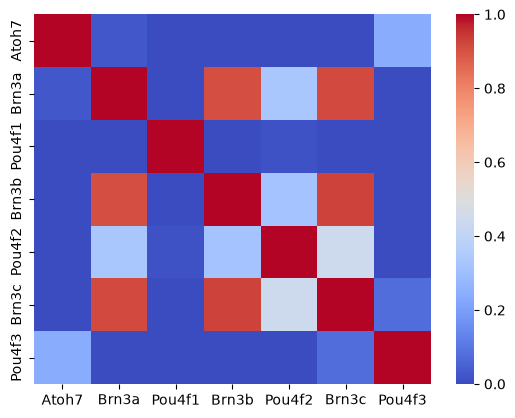

In [152]:
import seaborn as sns

sns.heatmap(
    control_cor,
    vmin=0,
    vmax=1,
    cmap='coolwarm',
)

<Axes: >

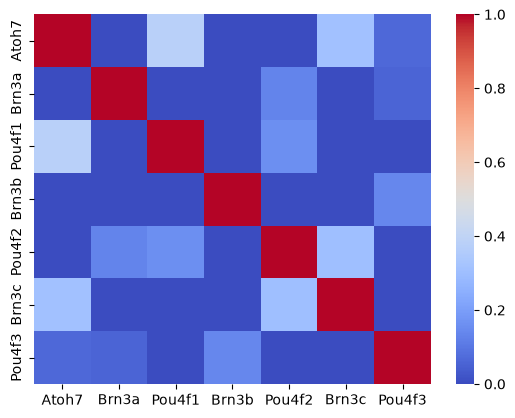

In [153]:
sns.heatmap(
    ld_cor,
    vmin=0,
    vmax=1,
    cmap='coolwarm',
)

Brn3a, Brn3b, and Brn3c are highly correlated in controls, but they are not correlated in the light deprivation group